In [3]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Jupyter 실행 위치가 ai/ 또는 ai/notebooks/여도 동작하도록 설정
cwd = Path.cwd().resolve()

if (cwd / "src").is_dir():
    project_root = cwd
elif (cwd.parent / "src").is_dir():
    project_root = cwd.parent
else:
    raise RuntimeError("ai 프로젝트 폴더에서 Jupyter를 실행하세요.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.baseline import JobInput, analyze_job, verify_evidence

print("프로젝트 경로:", project_root)
print("라이브러리 준비 완료")

프로젝트 경로: /Users/jeong-yelim/IF_portfolio/ai
라이브러리 준비 완료


In [4]:
# ============================================================
# 셀 2. 다중 라벨 분류 개념 실습
# ============================================================

# 1. 분류할 작업 특성 목록
labels = [
    "OUTDOOR",
    "HEAVY_LIFTING",
    "REPETITIVE_MOTION",
    "WALKING",
    "CLEANING",
]

# 2. 예시 직무에 포함된 작업 특성
active_tags = [
    "OUTDOOR",
    "WALKING",
    "CLEANING",
]

# 3. 작업 특성이 있으면 1, 없으면 0
label_vector = [
    int(label in active_tags)
    for label in labels
]

# 4. 표로 시각화
label_df = pd.DataFrame({
    "작업 특성": labels,
    "포함 여부": label_vector,
})

display(label_df)

print("다중 라벨 벡터:", label_vector)

# 5. 예상 결과 검증
assert label_vector == [1, 0, 0, 1, 1]

print("셀 2 검증 완료!")

,작업 특성,포함 여부
0,OUTDOOR,1
1,HEAVY_LIFTING,0
2,REPETITIVE_MOTION,0
3,WALKING,1
4,CLEANING,1


다중 라벨 벡터: [1, 0, 0, 1, 1]
셀 2 검증 완료!


In [5]:
# ============================================================
# 셀 3. 샘플 직무 데이터 생성
# ============================================================

# 1. 직무 데이터 5건 생성
sample_jobs = [
    {
        "jobId": 1,
        "jobTitle": "공원 환경관리",
        "description": "공원에서 걸어 다니며 쓰레기를 수거하고 청소한다.",
        "workHours": 4,
    },
    {
        "jobId": 2,
        "jobTitle": "물류 보조",
        "description": "창고에서 무거운 물건을 운반하고 상하차 작업을 한다.",
        "workHours": 6,
    },
    {
        "jobId": 3,
        "jobTitle": "제품 포장",
        "description": "제품을 반복적으로 포장하고 분류 작업을 한다.",
        "workHours": 5,
    },
    {
        "jobId": 4,
        "jobTitle": "사무 보조",
        "description": "서류를 정리하고 컴퓨터로 자료를 입력한다.",
        "workHours": 4,
    },
    {
        "jobId": 5,
        "jobTitle": "거리 환경정비",
        "description": "거리에서 도보로 이동하며 환경 정비와 청소를 수행한다.",
        "workHours": 5,
    },
]

# 2. Python 리스트를 DataFrame으로 변환
df = pd.DataFrame(sample_jobs)

# 3. 데이터 출력
display(df)

# 4. 데이터 구조 확인
print("전체 직무 수:", len(df))
print("행과 열:", df.shape)
print("컬럼:", df.columns.tolist())

# 5. 결과 검증
assert len(df) == 5
assert df.shape[1] == 4

print("셀 3 검증 완료!")

,jobId,jobTitle,description,workHours
0,1,공원 환경관리,공원에서 걸어 다니며 쓰레기를 수거하고 청소한다.,4
1,2,물류 보조,창고에서 무거운 물건을 운반하고 상하차 작업을 한다.,6
2,3,제품 포장,제품을 반복적으로 포장하고 분류 작업을 한다.,5
3,4,사무 보조,서류를 정리하고 컴퓨터로 자료를 입력한다.,4
4,5,거리 환경정비,거리에서 도보로 이동하며 환경 정비와 청소를 수행한다.,5


전체 직무 수: 5
행과 열: (5, 4)
컬럼: ['jobId', 'jobTitle', 'description', 'workHours']
셀 3 검증 완료!


===== 1. 데이터 기본 정보 =====
전체 데이터: 5 건
컬럼 목록: ['jobId', 'jobTitle', 'description', 'workHours']


,jobId,jobTitle,description,workHours
0,1,공원 환경관리,공원에서 걸어 다니며 쓰레기를 수거하고 청소한다.,4
1,2,물류 보조,창고에서 무거운 물건을 운반하고 상하차 작업을 한다.,6
2,3,제품 포장,제품을 반복적으로 포장하고 분류 작업을 한다.,5
3,4,사무 보조,서류를 정리하고 컴퓨터로 자료를 입력한다.,4
4,5,거리 환경정비,거리에서 도보로 이동하며 환경 정비와 청소를 수행한다.,5



===== 2. 결측치 검사 =====


,컬럼,결측치 수
0,jobId,0
1,jobTitle,0
2,description,0
3,workHours,0



===== 3. 빈 문자열 검사 =====
jobTitle: 0건
description: 0건

===== 4. 중복 검사 =====
중복 직무 ID: 0
중복 직무 설명: 0

===== 5. 근무시간 검사 =====
근무시간 이상치: 0 건


,jobId,jobTitle,description,workHours



===== 6. 직무 설명 길이 =====


,jobTitle,descriptionLength
0,공원 환경관리,27
1,물류 보조,29
2,제품 포장,25
3,사무 보조,23
4,거리 환경정비,30


count     5.000000
mean     26.800000
std       2.863564
min      23.000000
25%      25.000000
50%      27.000000
75%      29.000000
max      30.000000
Name: descriptionLength, dtype: float64

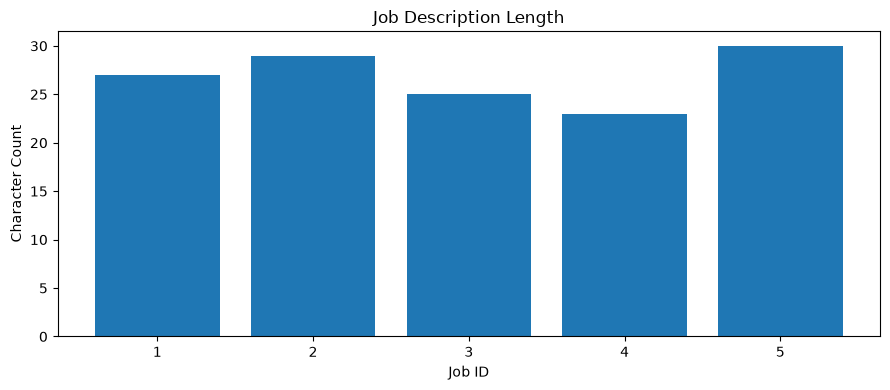


셀 4 데이터 품질 검증 완료!


In [6]:
# ============================================================
# 셀 4. EDA 및 데이터 품질 검증
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. 데이터 기본 정보
# ------------------------------------------------------------

print("===== 1. 데이터 기본 정보 =====")

print("전체 데이터:", len(df), "건")
print("컬럼 목록:", df.columns.tolist())

display(df.head())


# ------------------------------------------------------------
# 2. 결측치 검사
# ------------------------------------------------------------

print("\n===== 2. 결측치 검사 =====")

null_counts = df.isnull().sum()

display(
    null_counts.reset_index().rename(
        columns={
            "index": "컬럼",
            0: "결측치 수"
        }
    )
)


# ------------------------------------------------------------
# 3. 공백 문자열 검사
# ------------------------------------------------------------

print("\n===== 3. 빈 문자열 검사 =====")

for column in ["jobTitle", "description"]:

    empty_count = (
        df[column]
        .fillna("")
        .str.strip()
        .eq("")
        .sum()
    )

    print(f"{column}: {empty_count}건")


# ------------------------------------------------------------
# 4. 중복 데이터 검사
# ------------------------------------------------------------

print("\n===== 4. 중복 검사 =====")

duplicate_ids = df["jobId"].duplicated().sum()

duplicate_descriptions = (
    df["description"].duplicated().sum()
)

print("중복 직무 ID:", duplicate_ids)
print("중복 직무 설명:", duplicate_descriptions)


# ------------------------------------------------------------
# 5. 근무시간 이상치 검사
# ------------------------------------------------------------

print("\n===== 5. 근무시간 검사 =====")

invalid_hours = df[
    (df["workHours"] <= 0) |
    (df["workHours"] > 24)
]

print("근무시간 이상치:", len(invalid_hours), "건")

display(invalid_hours)


# ------------------------------------------------------------
# 6. 직무 설명 길이 분석
# ------------------------------------------------------------

print("\n===== 6. 직무 설명 길이 =====")

df["descriptionLength"] = (
    df["description"].fillna("").str.len()
)

display(
    df[
        ["jobTitle", "descriptionLength"]
    ]
)

display(df["descriptionLength"].describe())


# ------------------------------------------------------------
# 7. 시각화
# ------------------------------------------------------------

plt.figure(figsize=(9, 4))

plt.bar(
    df["jobId"].astype(str),
    df["descriptionLength"],
)

plt.title("Job Description Length")
plt.xlabel("Job ID")
plt.ylabel("Character Count")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. 최종 검증
# ------------------------------------------------------------

assert df["jobId"].is_unique
assert df["jobTitle"].notna().all()
assert df["description"].notna().all()
assert df["jobTitle"].str.strip().ne("").all()
assert df["description"].str.strip().ne("").all()
assert df["workHours"].between(1, 24).all()

print("\n셀 4 데이터 품질 검증 완료!")

In [7]:
# ============================================================
# 셀 5. AI-F-001 직무 작업 특성 자동 분류
# ============================================================

from src.models.baseline import JobInput, analyze_job

# 1. 분석 결과를 저장할 리스트
results = []

# 2. 샘플 직무 5건 순회
for row in sample_jobs:

    # 입력값 검증
    job = JobInput(**row)

    # 작업 특성 분석
    result = analyze_job(job)

    # 분석 결과 누적
    results.append(result)

# 3. 분석 결과를 표로 변환
result_df = pd.DataFrame([
    {
        "jobId": result["jobId"],
        "jobTitle": row["jobTitle"],
        "taskTags": ", ".join(result["taskTags"]),
        "tagCount": len(result["taskTags"]),
        "reviewRequired": result["reviewRequired"],
        "status": result["status"],
    }
    for row, result in zip(sample_jobs, results)
])

display(result_df)

# 4. 분석 건수 검증
assert len(results) == len(sample_jobs)

# 5. 원문 근거 검증
for row, result in zip(sample_jobs, results):
    assert verify_evidence(
        row["description"],
        result["evidence"],
    )

print("셀 5 작업 특성 분류 및 근거 검증 완료!")

,jobId,jobTitle,taskTags,tagCount,reviewRequired,status
0,1,공원 환경관리,"OUTDOOR, WALKING, CLEANING",3,True,REVIEW_REQUIRED
1,2,물류 보조,HEAVY_LIFTING,1,True,REVIEW_REQUIRED
2,3,제품 포장,REPETITIVE_MOTION,1,True,REVIEW_REQUIRED
3,4,사무 보조,,0,True,REVIEW_REQUIRED
4,5,거리 환경정비,"OUTDOOR, WALKING, CLEANING",3,True,REVIEW_REQUIRED


셀 5 작업 특성 분류 및 근거 검증 완료!


===== 작업 특성별 빈도 =====


,taskTag,count
0,OUTDOOR,2
1,WALKING,2
2,CLEANING,2
3,HEAVY_LIFTING,1
4,REPETITIVE_MOTION,1


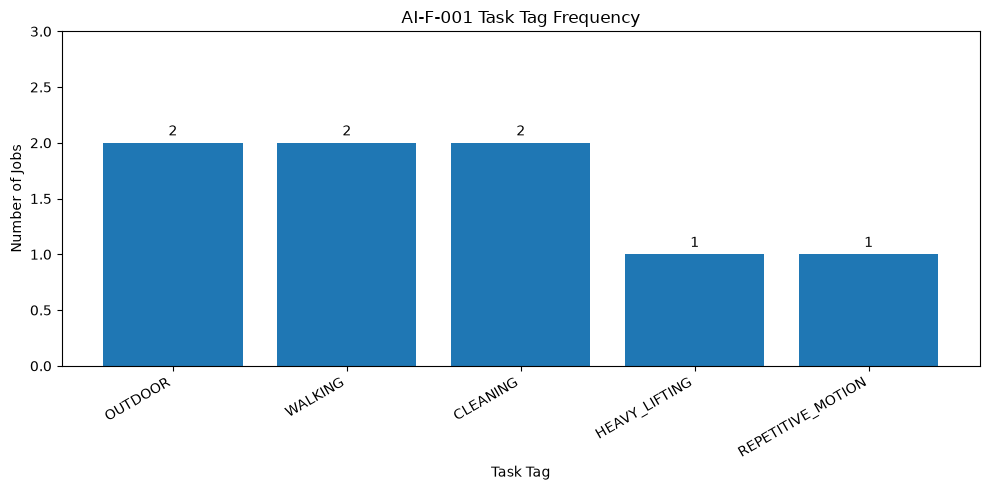

셀 6 태그 빈도 분석 완료!


In [8]:
# ============================================================
# 셀 6. 작업 특성 태그별 빈도 분석 및 시각화
# ============================================================

from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

# 1. 모든 작업 특성 태그의 개수 집계
tag_counter = Counter()

for result in results:
    tag_counter.update(result["taskTags"])

# 2. DataFrame 생성
# labels를 사용하여 0건인 태그도 표시
tag_df = pd.DataFrame({
    "taskTag": labels,
    "count": [tag_counter[tag] for tag in labels],
})

# 3. 많이 등장한 태그부터 정렬
tag_df = tag_df.sort_values(
    by="count",
    ascending=False,
).reset_index(drop=True)

print("===== 작업 특성별 빈도 =====")
display(tag_df)

# 4. 막대그래프 시각화
plt.figure(figsize=(10, 5))

bars = plt.bar(
    tag_df["taskTag"],
    tag_df["count"],
)

# 막대 위에 건수 표시
plt.bar_label(bars, padding=3)

plt.title("AI-F-001 Task Tag Frequency")
plt.xlabel("Task Tag")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, max(tag_df["count"]) + 1)

plt.tight_layout()
plt.show()

# 5. 결과 검증
assert tag_counter["OUTDOOR"] == 2
assert tag_counter["WALKING"] == 2
assert tag_counter["CLEANING"] == 2
assert tag_counter["HEAVY_LIFTING"] == 1
assert tag_counter["REPETITIVE_MOTION"] == 1

print("셀 6 태그 빈도 분석 완료!")

===== 작업 특성 매트릭스 =====


,OUTDOOR,HEAVY_LIFTING,REPETITIVE_MOTION,WALKING,CLEANING
공원 환경관리,1,0,0,1,1
물류 보조,0,1,0,0,0
제품 포장,0,0,1,0,0
사무 보조,0,0,0,0,0
거리 환경정비,1,0,0,1,1


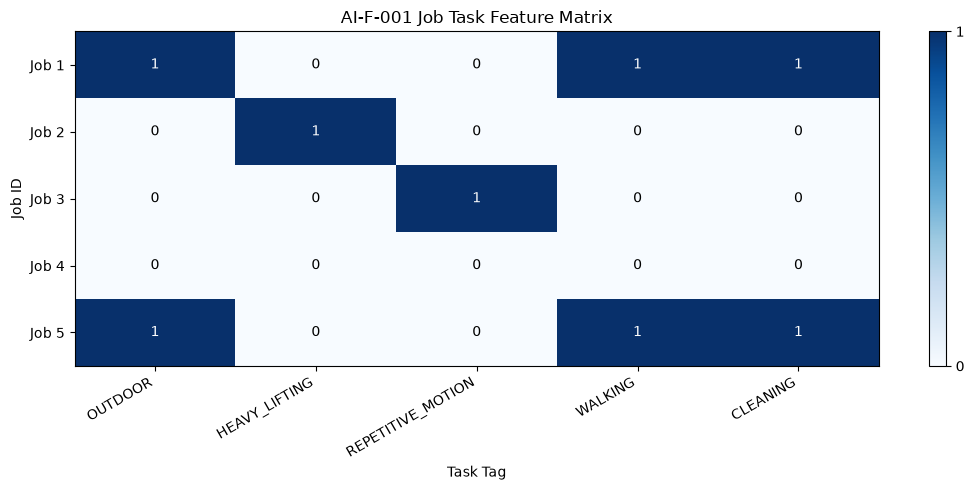

셀 7 작업 특성 매트릭스 완료!


In [10]:
# ============================================================
# 셀 7. 직무 × 작업 특성 매트릭스 시각화
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# 1. 직무별 태그를 0과 1로 변환
matrix_data = []

for result in results:
    row = [
        int(tag in result["taskTags"])
        for tag in labels
    ]
    matrix_data.append(row)

# 2. DataFrame 생성
tag_matrix = pd.DataFrame(
    matrix_data,
    columns=labels,
    index=[job["jobTitle"] for job in sample_jobs],
)

print("===== 작업 특성 매트릭스 =====")
display(tag_matrix)

# 3. Heatmap 그리기
fig, ax = plt.subplots(figsize=(11, 5))

im = ax.imshow(
    tag_matrix.values,
    cmap="Blues",
    vmin=0,
    vmax=1,
    aspect="auto",
)

# 4. X축: 작업 특성
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right")

# 5. Y축: 직무명 대신 Job ID 사용
# 한글 폰트가 없어도 정상 표시되도록 설정
ax.set_yticks(range(len(sample_jobs)))
ax.set_yticklabels([
    f"Job {job['jobId']}"
    for job in sample_jobs
])

# 6. 각 칸에 0 또는 1 표시
for i in range(len(sample_jobs)):
    for j in range(len(labels)):
        value = tag_matrix.iloc[i, j]

        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color="white" if value == 1 else "black",
        )

plt.colorbar(im, ax=ax, ticks=[0, 1])
plt.title("AI-F-001 Job Task Feature Matrix")
plt.xlabel("Task Tag")
plt.ylabel("Job ID")
plt.tight_layout()
plt.show()

# 7. 결과 검증
assert tag_matrix.shape == (5, 5)
assert tag_matrix.values.sum() == 8

print("셀 7 작업 특성 매트릭스 완료!")

In [11]:
# AI-F-001 / AT-004 원문 근거 검증

validation_results = []

for job, result in zip(sample_jobs, results):
    valid = verify_evidence(
        job["description"],
        result["evidence"]
    )

    validation_results.append({
        "jobId": job["jobId"],
        "evidenceCount": len(result["evidence"]),
        "evidenceValid": valid,
    })

validation_df = pd.DataFrame(validation_results)
display(validation_df)

assert validation_df["evidenceValid"].all()

print("Baseline 실습 완료! FastAPI 개발 준비 완료")

,jobId,evidenceCount,evidenceValid
0,1,4,True
1,2,2,True
2,3,3,True
3,4,0,True
4,5,4,True


Baseline 실습 완료! FastAPI 개발 준비 완료
